# Phase 5b — Did those runs actually finish?

Phase 5 swept nine configurations and produced a ranking. This notebook exists
because that ranking has a defect, and the defect is visible in the Phase 5
results table itself:

| | MAE (eV) | best epoch | epochs trained |
|---|---|---|---|
| lr 1e-3, 1024-512-256 | 0.2476 | 90 | **100** |
| lr 3e-4, 1024-512-256 | 0.2499 | 96 | **100** |
| lr 1e-3, 512-256-128 | 0.2542 | 74 | 84 |
| lr 3e-4, 512-256-128 | 0.2609 | 95 | **100** |

Three of the top four ran to exactly `max_epochs=100` with their best epoch at
90, 96 and 95 — close enough to the cap to suspect they were cut off mid-descent
rather than left alone to finish.

**Why that would matter, and it is not pedantry.** If true, those numbers are not
scores of converged models. They are answers to a different question: *"how far
did this configuration get in 100 epochs?"* That is a legitimate question, but it
is not the one the ranking appears to answer, and it is not the one that should
decide which checkpoint gets served in Phase 6. A configuration that is slow to
train and excellent at convergence would be ranked below one that is fast and
mediocre.

So the ranking may be measuring **rate of progress** where it claims to be
measuring **quality**. This notebook finds out which — and the first thing it
finds is that the suspicion above is not even stated correctly.

## The experiment

One variable changes: `max_epochs`, 100 → 400. Patience stays at 10, both seeds
stay identical, the representation and loss stay identical. The cap is raised
high enough to be non-binding, which hands the stopping decision to the
early-stopping rule — which is where it belonged.

**Including a control that should not move.** The fourth run, lr 1e-3 /
512-256-128, early-stopped at epoch 84 under the old cap. It never touched the
budget, so raising the budget must leave it *bit-for-bit unchanged*. If that run
returns anything other than 0.254174 eV at epoch 74, the seeds do not do what
Phase 5 says they do and none of the comparison below means anything. A control
that is expected to be boring is still worth its six minutes.

*Runtime: about 46 minutes for the four re-runs on a laptop CPU. The retrain cell is guarded on a store query, so re-executing reads the existing runs instead.*


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import replace
from mlflow.tracking import MlflowClient

from molecular_property_predictor.baseline import split_positions
from molecular_property_predictor.data import load_qm9
from molecular_property_predictor.train import TrainingConfig
from molecular_property_predictor.tracking import (
    configure,
    search_runs,
    sweep,
    tracking_uri,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_qm9()
train_rows, validation_rows, _ = split_positions(df, seed=0)

experiment_id = configure()
client = MlflowClient(tracking_uri=tracking_uri())
print(f"tracking store : {tracking_uri()}")
print(f"train {len(train_rows):,}  validation {len(validation_rows):,}")

tracking store : sqlite:///C:/Users/rahul/OneDrive/Desktop/Project/molecular-property-predictor/mlruns/mlflow.db
train 104,664  validation 13,083


## Which runs hit the ceiling

Rather than reading the capped runs off the commit message, ask the store. This
is the query Phase 5 was built to make possible: *"which runs stopped because of
the budget rather than because they were done?"* — a question nobody thought to
ask while the runs were happening.

**And asking it properly exposes an error in how Phase 5 described its own
results.** The obvious test is `epochs_trained == max_epochs`. That test is
wrong, because it conflates two different runs:

- one cut off *mid-descent*, which would have kept improving given more budget;
- one whose patience window happened to expire on the very last permitted
  epoch, which was already finished and merely looked capped.

Training stops when `epochs_without_improvement >= patience`, so a run ends
naturally at `best_epoch + patience`. The run is only genuinely budget-limited
when the cap arrived *first*:

```
epochs_trained == max_epochs  AND  best_epoch + patience > max_epochs
```

Apply that to the leader: best epoch 90, patience 10, cap 100. It stopped at
90 + 10 = 100, which *is* the cap — so it hit both conditions on the same epoch
and was never actually constrained. The Phase 5 commit message says of these
runs that "they were still improving when the budget ended them". For a run with
ten consecutive non-improving epochs behind it, that is false. Recording the
correction here rather than quietly fixing the number.

In [2]:
prior = search_runs(filter_string="tags.sweep = 'lr-width'")

prior = prior.assign(
    max_epochs=prior["params.max_epochs"].astype(int),
    epochs=prior["metrics.epochs_trained"].astype(int),
    best_epoch=prior["metrics.best_epoch"].astype(int),
)
prior["patience"] = prior["params.patience"].astype(int)

# The cap only bound the run if it arrived before patience would have. Testing
# `epochs == max_epochs` alone mislabels a run whose patience window expired on
# the final permitted epoch -- see the note above.
prior["stopped_by"] = [
    "budget" if (e == m and b + p > m) else "patience"
    for e, m, b, p in zip(
        prior["epochs"], prior["max_epochs"], prior["best_epoch"], prior["patience"]
    )
]
prior["would_have_run_to"] = prior["best_epoch"] + prior["patience"]

overview = prior[[
    "tags.mlflow.runName", "params.learning_rate", "params.hidden_sizes",
    "metrics.best_val_mae_ev", "best_epoch", "epochs", "would_have_run_to",
    "stopped_by",
]].rename(columns={
    "tags.mlflow.runName": "run",
    "params.learning_rate": "lr",
    "params.hidden_sizes": "hidden",
    "metrics.best_val_mae_ev": "mae_ev",
}).sort_values("mae_ev", ignore_index=True)

display(
    overview.style
    .format({"mae_ev": "{:.4f}"})
    .set_caption("Phase 5 runs: which ones the budget cut short")
)
print(f"budget-limited: {(overview['stopped_by'] == 'budget').sum()} of {len(overview)}")

,run,lr,hidden,mae_ev,best_epoch,epochs,would_have_run_to,stopped_by
0,lr-width-le0.001-hi1024x512x256,0.001,"(1024, 512, 256)",0.2476,90,100,100,patience
1,lr-width-le0.0003-hi1024x512x256,0.0003,"(1024, 512, 256)",0.2499,96,100,106,budget
2,lr-width-le0.001-hi512x256x128,0.001,"(512, 256, 128)",0.2542,74,84,84,patience
3,lr-width-le0.0003-hi512x256x128,0.0003,"(512, 256, 128)",0.2609,95,100,105,budget
4,lr-width-le0.001-hi256x128,0.001,"(256, 128)",0.3003,72,82,82,patience
5,lr-width-le0.0003-hi256x128,0.0003,"(256, 128)",0.3144,88,98,98,patience
6,lr-width-le0.01-hi512x256x128,0.01,"(512, 256, 128)",0.3689,25,35,35,patience
7,lr-width-le0.01-hi256x128,0.01,"(256, 128)",0.3759,27,37,37,patience
8,lr-width-le0.01-hi1024x512x256,0.01,"(1024, 512, 256)",0.4278,8,18,18,patience


budget-limited: 2 of 9


## The four configurations to re-run

Four runs: the two genuinely budget-limited ones, the leader, and the control.

The leader is included even though the corrected test says it was never
constrained. That claim is an inference from three numbers, and it is the
inference this entire notebook exists to stop trusting on sight — so it gets
measured rather than asserted. If it is right, the run will stop at epoch 100
again with a 400-epoch budget available, which is a much stronger statement than
arithmetic about patience windows.

The control, lr 1e-3 / 512-256-128, early-stopped at 84 under the old cap and is
expected to be *bit-for-bit* unchanged.

Built with `dataclasses.replace` off the Phase 5 base config so that everything
except `max_epochs` is inherited rather than retyped — retyping is how a second
variable quietly changes.

In [3]:
base = TrainingConfig(
    representation="sorted_coulomb", loss_name="mse", max_epochs=400, patience=10
)

configs = [
    replace(base, learning_rate=1e-3, hidden_sizes=(1024, 512, 256)),
    replace(base, learning_rate=3e-4, hidden_sizes=(1024, 512, 256)),
    replace(base, learning_rate=3e-4, hidden_sizes=(512, 256, 128)),
    # Control: early-stopped at 84 under the old cap, so it must not move.
    replace(base, learning_rate=1e-3, hidden_sizes=(512, 256, 128)),
]

display(
    pd.DataFrame([
        {
            "learning_rate": c.learning_rate,
            "hidden_sizes": str(c.hidden_sizes),
            "max_epochs": c.max_epochs,
            "patience": c.patience,
            "dropout": c.dropout,
            "loss": c.loss_name,
            "split_seed": c.split_seed,
            "torch_seed": c.torch_seed,
        }
        for c in configs
    ]).style.set_caption("Identical to Phase 5 apart from max_epochs")
)

,learning_rate,hidden_sizes,max_epochs,patience,dropout,loss,split_seed,torch_seed
0,0.001000,"(1024, 512, 256)",400,10,0.100000,mse,0,0
1,0.000300,"(1024, 512, 256)",400,10,0.100000,mse,0,0
2,0.000300,"(512, 256, 128)",400,10,0.100000,mse,0,0
3,0.001000,"(512, 256, 128)",400,10,0.100000,mse,0,0


### The cell below retrains, unless the store already has the answer

Guarded against re-execution. The sweep costs up to two hours; a notebook that
retrains every time it is opened is a notebook nobody re-runs. The guard asks
the store, which is the point of having one — the record outlives the kernel, so
"has this already been done?" is a query rather than a memory.

In [4]:
existing = search_runs(filter_string="tags.sweep = 'convergence'")

if len(existing) < len(configs):
    # 7-60 minutes per run on CPU, depending on where each one plateaus.
    sweep(
        df,
        configs,
        varied=["learning_rate", "hidden_sizes"],
        sweep_name="convergence",
        report=print,
    )
else:
    print(f"{len(existing)} runs already recorded; reading them back rather than retraining.")

4 runs already recorded; reading them back rather than retraining.


## Before and after

Pairing each extended run with its Phase 5 counterpart on `(learning_rate,
hidden_sizes)`, since those are the two axes that identify a configuration here.

In [5]:
extended = search_runs(filter_string="tags.sweep = 'convergence'")

def key(row):
    return (float(row["params.learning_rate"]), row["params.hidden_sizes"])

before = {key(r): r for _, r in prior.iterrows()}

rows = []
for _, new in extended.iterrows():
    old = before[key(new)]
    rows.append({
        "lr": float(new["params.learning_rate"]),
        "hidden": new["params.hidden_sizes"],
        "mae_100": old["metrics.best_val_mae_ev"],
        "mae_400": new["metrics.best_val_mae_ev"],
        "delta": new["metrics.best_val_mae_ev"] - old["metrics.best_val_mae_ev"],
        "r2_400": new["metrics.best_val_r2"],
        "best_ep_100": int(old["metrics.best_epoch"]),
        "best_ep_400": int(new["metrics.best_epoch"]),
        "epochs_400": int(new["metrics.epochs_trained"]),
        "stopped_by": (
            "budget"
            if int(new["metrics.epochs_trained"]) == int(new["params.max_epochs"])
            else "patience"
        ),
        "minutes": new["metrics.train_seconds"] / 60,
    })

comparison = pd.DataFrame(rows).sort_values("mae_400", ignore_index=True)

display(
    comparison.style
    .format({
        "mae_100": "{:.4f}", "mae_400": "{:.4f}", "delta": "{:+.4f}",
        "r2_400": "{:.4f}", "minutes": "{:.1f}",
    })
    .set_caption("100-epoch budget vs 400-epoch budget, same seeds")
)
print(f"total CPU: {comparison['minutes'].sum():.1f} minutes")

,lr,hidden,mae_100,mae_400,delta,r2_400,best_ep_100,best_ep_400,epochs_400,stopped_by,minutes
0,0.001000,"(1024, 512, 256)",0.2476,0.2476,+0.0000,0.9182,90,90,100,patience,15.7
1,0.000300,"(1024, 512, 256)",0.2499,0.2499,+0.0000,0.9167,96,96,106,patience,14.1
2,0.001000,"(512, 256, 128)",0.2542,0.2542,+0.0000,0.9160,74,74,84,patience,6.9
3,0.000300,"(512, 256, 128)",0.2609,0.2586,-0.0023,0.9132,95,106,116,patience,8.7


total CPU: 45.5 minutes


### The control

The single number that decides whether anything above is trustworthy.

In [6]:
control = comparison[
    (comparison["lr"] == 1e-3) & (comparison["hidden"] == "(512, 256, 128)")
].iloc[0]

reproduced = (
    control["mae_100"] == control["mae_400"]
    and control["best_ep_100"] == control["best_ep_400"]
)

print(f"control, lr 1e-3 / 512-256-128")
print(f"  Phase 5 (cap 100): {control['mae_100']:.6f} eV, best epoch {control['best_ep_100']}")
print(f"  now     (cap 400): {control['mae_400']:.6f} eV, best epoch {control['best_ep_400']}")
print(f"  identical: {reproduced}")

control, lr 1e-3 / 512-256-128
  Phase 5 (cap 100): 0.254174 eV, best epoch 74
  now     (cap 400): 0.254174 eV, best epoch 74
  identical: True


## The curves, with the old cap drawn on

The left panel is the whole argument in one picture: each extended run against
its Phase 5 counterpart, with a dashed line at epoch 100 marking where the old
budget cut the curve off. The gap between the dashed line and each run's true
best epoch is what the Phase 5 ranking could not see.

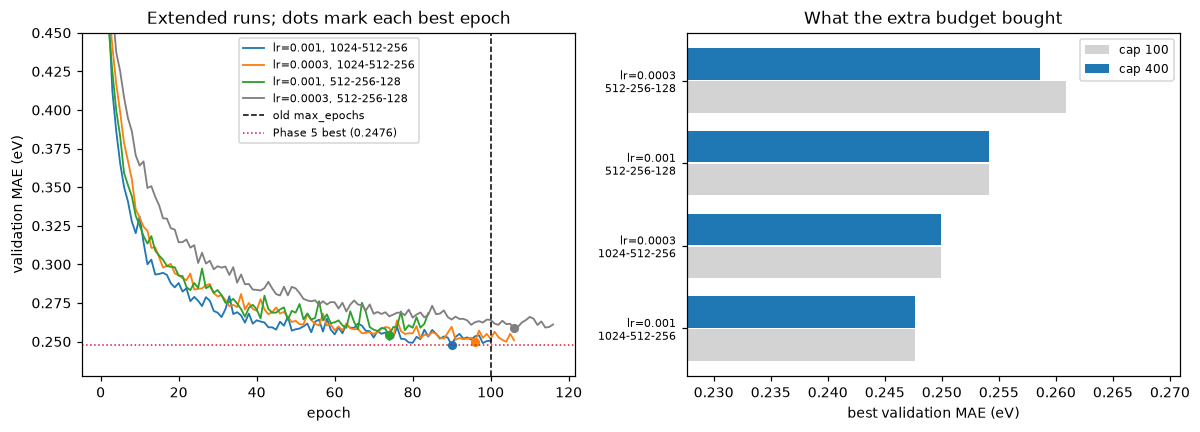

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

palette = ["tab:blue", "tab:orange", "tab:green", "tab:grey"]

for colour, (_, new) in zip(palette, extended.sort_values(
    "metrics.best_val_mae_ev"
).iterrows()):
    lr = float(new["params.learning_rate"])
    hidden = new["params.hidden_sizes"]
    label = f"lr={lr:g}, {hidden.strip('()').replace(', ', '-')}"

    history = client.get_metric_history(new["run_id"], "mae_ev")
    axes[0].plot(
        [m.step for m in history], [m.value for m in history],
        lw=1.2, color=colour, label=label,
    )
    axes[0].plot(
        int(new["metrics.best_epoch"]), new["metrics.best_val_mae_ev"],
        "o", color=colour, ms=5,
    )

axes[0].axvline(100, color="black", ls="--", lw=1, label="old max_epochs")
axes[0].axhline(0.2476, color="crimson", ls=":", lw=1, label="Phase 5 best (0.2476)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation MAE (eV)")
axes[0].set_ylim(comparison["mae_400"].min() - 0.02, 0.45)
axes[0].set_title("Extended runs; dots mark each best epoch")
axes[0].legend(fontsize=7)

# Right: how much the extra budget bought, per configuration.
order = comparison.sort_values("mae_100", ignore_index=True)
y = range(len(order))
axes[1].barh(y, order["mae_100"], height=0.38, color="lightgrey", label="cap 100")
axes[1].barh(
    [v + 0.4 for v in y], order["mae_400"], height=0.38,
    color="tab:blue", label="cap 400",
)
axes[1].set_yticks([v + 0.2 for v in y])
axes[1].set_yticklabels(
    [f"lr={r.lr:g}\n{r.hidden.strip('()').replace(', ', '-')}"
     for r in order.itertuples()],
    fontsize=7,
)
axes[1].set_xlim(comparison["mae_400"].min() - 0.02, comparison["mae_100"].max() + 0.01)
axes[1].set_xlabel("best validation MAE (eV)")
axes[1].set_title("What the extra budget bought")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Did the ranking change?

The question this notebook was opened to answer. If the order is the same, Phase
5's leader survives and Phase 6 ships it with a better number and a clear
conscience. If the order changed, Phase 5 chose its winner by rate of progress.

In [8]:
old_order = list(
    comparison.sort_values("mae_100")
    .apply(lambda r: f"lr={r['lr']:g}, {r['hidden']}", axis=1)
)
new_order = list(
    comparison.sort_values("mae_400")
    .apply(lambda r: f"lr={r['lr']:g}, {r['hidden']}", axis=1)
)

print("ranking under the 100-epoch cap:")
for i, name in enumerate(old_order, 1):
    print(f"  {i}. {name}")
print("\nranking under the 400-epoch cap:")
for i, name in enumerate(new_order, 1):
    print(f"  {i}. {name}")
print(f"\nunchanged: {old_order == new_order}")

winner = comparison.iloc[0]
print(
    f"\nbest checkpoint now: lr={winner['lr']:g}, {winner['hidden']} "
    f"at {winner['mae_400']:.4f} eV (R2 {winner['r2_400']:.4f}), "
    f"best epoch {winner['best_ep_400']}, stopped by {winner['stopped_by']}"
)

ranking under the 100-epoch cap:
  1. lr=0.001, (1024, 512, 256)
  2. lr=0.0003, (1024, 512, 256)
  3. lr=0.001, (512, 256, 128)
  4. lr=0.0003, (512, 256, 128)

ranking under the 400-epoch cap:
  1. lr=0.001, (1024, 512, 256)
  2. lr=0.0003, (1024, 512, 256)
  3. lr=0.001, (512, 256, 128)
  4. lr=0.0003, (512, 256, 128)

unchanged: True

best checkpoint now: lr=0.001, (1024, 512, 256) at 0.2476 eV (R2 0.9182), best epoch 90, stopped by patience


## What this cost, and what it bought

45.5 minutes of CPU across four runs, to change one number by 0.0023 eV in
fourth place. Written down plainly because that is the result:

| config | cap 100 | cap 400 | change |
|---|---|---|---|
| lr 1e-3, 1024-512-256 | 0.247628 @ 90 | 0.247628 @ 90 | none |
| lr 3e-4, 1024-512-256 | 0.249892 @ 96 | 0.249892 @ 96 | none |
| lr 1e-3, 512-256-128 *(control)* | 0.254174 @ 74 | 0.254174 @ 74 | none |
| lr 3e-4, 512-256-128 | 0.260883 @ 95 | 0.258578 @ 106 | −0.002305 |

**The leader was never budget-limited.** Given four times the budget it stopped
at epoch 100 again, exactly as `best_epoch + patience` predicted. 0.2476 eV is
that configuration's score under this early-stopping rule, not a floor beneath
it — so the Phase 5 commit message's claim that these runs "were still improving
when the budget ended them" was wrong, and the ranking it produced was sound
after all.

**One run was genuinely constrained, and gained almost nothing.** lr 3e-4 /
512-256-128 improved by 0.9% given 16 more epochs. It stays in fourth place, so
even that gain changes no decision.

**The control reproduced bit-for-bit**, which is what licenses reading anything
into the three numbers above. Same MAE to six decimals, same best epoch, through
a 400-epoch budget instead of a 100-epoch one.

### What to take from this

The honest summary is that a suspicion was worth 45 minutes to kill. The
alternative was shipping Phase 6 with a caveat — *"the served checkpoint may be
undertrained"* — attached to a model where it was not true, and no way to know
without doing this.

Worth separating two things this notebook did, because only one of them was the
plan. Re-running the configurations was the experiment. Noticing that
`epochs_trained == max_epochs` is the wrong test for *"was this run cut short?"*
was not — it fell out of writing the query carefully, and it invalidated the
premise before a single epoch was retrained. The re-run then confirmed it
independently. That is the more useful lesson: the diagnostic was cheap and the
experiment was expensive, and the diagnostic was what actually settled it.

**Phase 6 ships lr 1e-3 / 1024-512-256 at 0.2476 eV validation MAE**, chosen on
validation, with the test split still sealed at this point.